In [1]:
using DriftDiffusionModels
using DataFrames
using Dates
using CSV
using Plots


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
ddir = "../data/mouse_df.csv"
# load in the data
df = CSV.File(ddir) |> DataFrame;

In [3]:
# Group by animal name and count trials
trial_counts = combine(groupby(df, :name), nrow => :trial_count)

# Sort by count in descending order
sort!(trial_counts, :trial_count, rev=true)

# pick a mouse of interest (start with mouse of most trials)
moi = trial_counts[1, :name]

# get the data for the mouse of interest
mouse_df = df[df.name .== moi, :]

# Filter out trials with "omission" outcome
valid_trials = findall(outcome -> outcome != "omission", mouse_df.outcome)
filtered_df = mouse_df[valid_trials, :]

# Map correct -> 1 and incorrect -> -1 (only for error and correct, omissions are gone)
numeric_outcomes = [outcome == "correct" ? 1 : -1 for outcome in filtered_df.outcome]

# Get reaction times, filter out "NAN" values
valid_rt_indices = findall(rt -> uppercase(string(rt)) != "NAN", filtered_df.rt)
# valid_trials = findall(rt -> rt > 0.2, filtered_df.rt)

# Apply both filters to keep data aligned
final_df = filtered_df[valid_rt_indices, :]
final_outcomes = numeric_outcomes[valid_rt_indices]

# Convert RTs to Float64
# final_rts = [parse(Float64, rt) for rt in final_df.rt]
final_rts = final_df.rt
final_stimulus = final_df.correct_side
final_stimulus = [stim == "right" ? 1 : -1 for stim in final_stimulus]

# Extract just the date part from the timestamp strings
dates = [Date(split(dt)[1]) for dt in final_df.trial_datetime]

# Get unique dates in chronological order
unique_dates = sort(unique(dates))

# Create a vector of vectors, where each inner vector contains DDMResults for one day
results_by_date = Vector{Vector{DDMResult}}()

for date in unique_dates
    # Get indices for this date
    day_indices = findall(dates .== date)
    
    # Skip days with no valid data
    if isempty(day_indices)
        continue
    end
    
    # Extract RTs and outcomes for this date
    day_rts = final_rts[day_indices]
    day_outcomes = final_outcomes[day_indices]
    day_stim_side = final_stimulus[day_indices]
    
    # Create DDMResult objects for this day
    day_results = [DDMResult(rt, choice, stim) for (rt, choice, stim) in zip(day_rts, day_outcomes, day_stim_side)]

    # Add to our vector of vectors
    push!(results_by_date, day_results)
end

# Now calculate the sequence ends (cumulative sum of lengths)
seq_ends = cumsum([length(seq) for seq in results_by_date])

# Concatenate all results into a single vector
all_results = reduce(vcat, results_by_date)

12311-element Vector{DDMResult}:
 DDMResult(0.2716, 1, -1)
 DDMResult(0.4124, -1, 1)
 DDMResult(0.2669, 1, -1)
 DDMResult(0.8428, 1, 1)
 DDMResult(0.3541, 1, 1)
 DDMResult(0.247, 1, -1)
 DDMResult(0.4099, 1, -1)
 DDMResult(0.2372, -1, -1)
 DDMResult(0.3275, -1, 1)
 DDMResult(0.2344, 1, 1)
 ⋮
 DDMResult(0.4864, 1, 1)
 DDMResult(0.2847, -1, -1)
 DDMResult(0.2424, 1, 1)
 DDMResult(0.4899, -1, -1)
 DDMResult(0.226, -1, -1)
 DDMResult(0.2562, -1, -1)
 DDMResult(0.5747, 1, -1)
 DDMResult(0.3208, 1, 1)
 DDMResult(0.4196, 1, -1)

In [8]:
hyper, qs, elbo_history = fit_vi_gaussian(all_results; n_iter=25, K=25, verbose=true)

Data-driven init: B=0.778, τ=0.234, v=0.655
VI iter 1
  ELBO: -32373.536311616037
VI iter 2
  ELBO: -18209.221723803134
VI iter 3
  ELBO: -14071.635281641955
VI iter 4
  ELBO: -11625.230063770092
VI iter 5
  ELBO: -9428.69289285919
VI iter 6
  ELBO: -8076.90694563092
VI iter 7
  ELBO: -7219.003683117979
VI iter 8
  ELBO: -6535.056305054261
VI iter 9
  ELBO: -5872.064379639909
VI iter 10
  ELBO: -5384.681805795142
VI iter 11
  ELBO: -4925.426048512693
VI iter 12
  ELBO: -4702.300090456376
VI iter 13
  ELBO: -4429.827951968355
VI iter 14
  ELBO: -4164.155981342997
VI iter 15
  ELBO: -4036.839421959563
VI iter 16
  ELBO: -3966.410043471103
VI iter 17
  ELBO: -3661.92950934152
VI iter 18
  ELBO: -3620.4725279555964
VI iter 19
  ELBO: -3403.3528436136025
VI iter 20
  ELBO: -3372.1183904054938
VI iter 21
  ELBO: -3257.2472712185145
VI iter 22
  ELBO: -3166.3160082565496
VI iter 23
  ELBO: -3177.5619287834415
VI iter 24
  ELBO: -2990.748021884046
VI iter 25
  ELBO: -2905.5890284139837


(DriftDiffusionModels.DDMHyper{Float64}([-0.15334025812430682, -1.611067324118645, -0.6182427279791811, 0.1759141515966597], [-1.2708812569822583, -2.225681700697399, -0.2940275972221241, -1.2580502096132118]), DriftDiffusionModels.TrialVIParams{Float64}[DriftDiffusionModels.TrialVIParams{Float64}([-0.25310376236712545, -1.6012185423024436, -0.7712480762115304, 0.2305499085217124], [-1.4291251713687576, -2.326603206086156, -0.4036588428234846, -1.3037526587052224]), DriftDiffusionModels.TrialVIParams{Float64}([-0.14273776368710928, -1.5952450138601095, -0.8337959007676551, 0.1399534239747581], [-1.4472526172969447, -2.2195222209435297, -0.4171965261280355, -1.2719280603573664]), DriftDiffusionModels.TrialVIParams{Float64}([-0.2667437944980353, -1.609071197034727, -0.7348310903141644, 0.23859262413472324], [-1.411564736309057, -2.3943166215280454, -0.34495163716921656, -1.2833510178252152]), DriftDiffusionModels.TrialVIParams{Float64}([0.0822291488321634, -1.6004117310659725, -0.5565463

In [9]:
B = [exp(i.μ[1]) for i in qs]          # boundary separation
τ = [exp(i.μ[2]) for i in qs]          # non-decision time
v = [exp(i.μ[3]) for i in qs]          # drift rate
a0 = [1 / (1 + exp(-i.μ[4])) for i in qs]  # starting point

12311-element Vector{Float64}:
 0.5573835252300388
 0.5349313580028133
 0.5593667945167505
 0.5401380028712315
 0.5429032725829928
 0.5645960320712897
 0.5464391805077842
 0.5184556689439372
 0.5346105975216203
 0.5632041838874291
 ⋮
 0.5393802080364225
 0.5313385419251981
 0.5663596948697822
 0.5443817472487654
 0.5137338096332741
 0.5245753335961293
 0.5447545989058669
 0.5465485992816692
 0.548339106496375

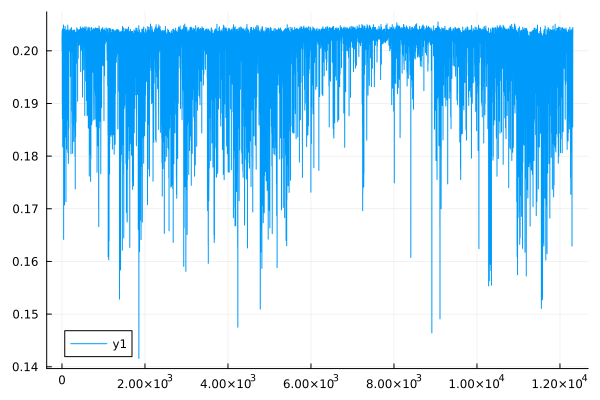

In [20]:
plot(τ)

In [18]:
DriftDiffusionModels.transform_params(hyper.m)

(0.8578377858714425, 0.5388905833778957, 0.5438654752224363, 0.19967438301719156)

In [30]:
using StatsBase
pacf(a0, 1:20)

20-element Vector{Float64}:
 -0.0136119002349834
  0.011786931384765121
  0.0006543893847537557
  0.003611706736453181
 -0.006808132405105995
  0.005452539221339849
 -0.01956395146746668
 -0.00469687131190715
  0.014789605107811712
  0.0024046756337786027
  0.003947262266555507
  0.0073377053268253185
 -0.0020236795912414065
 -0.0011494149678229091
 -0.016681861795819757
  0.02471446918133339
 -0.009463143692191821
  0.014478005775256715
 -0.0008464259694418477
  0.012041780639973463